# Basic concepts - Nodes, Edges & States

In [1]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

In [2]:
class InputState(TypedDict):
    string_value:str
    numeric_value: int

In [3]:
def modify_state(input: InputState):
    print(f"Current value: {input}")
    return input

In [4]:
graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)

graph.add_edge(START, "branch_a")
graph.add_edge("branch_a","branch_b")
graph.add_edge("branch_b", END)

graph.set_entry_point("branch_a")


In [5]:
runnable = graph.compile()

## Vusyakuze graph

In [6]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

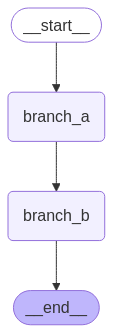

In [7]:
display(
    Image(
        runnable.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [8]:
runnable.invoke({"string_value": "a"})

Current value: {'string_value': 'a'}
Current value: {'string_value': 'a'}


{'string_value': 'a'}

In [9]:
runnable.invoke({"string_value": "a", "numeric_value": 1})

Current value: {'string_value': 'a', 'numeric_value': 1}
Current value: {'string_value': 'a', 'numeric_value': 1}


{'string_value': 'a', 'numeric_value': 1}

In [10]:
def modify_state(input: InputState):
    input["string_value"] += "a"
    input["numeric_value"] += 1
    return input


graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)
graph.add_edge("branch_a", "branch_b")
graph.add_edge("branch_b", END)


graph.set_entry_point("branch_a")

runnable = graph.compile()

In [11]:
try:
    runnable.invoke({"string_value": "a"})
except KeyError as e:
    print(e)

'numeric_value'


In [12]:
runnable.invoke({"string_value": "a", "numeric_value": 1})

{'string_value': 'aaa', 'numeric_value': 3}